In [201]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [93]:
cm_eco = gpd.read_file('../../data/Ecoregions/CM_Ecoregions.shp')

In [94]:
month_labels = ["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"]

In [95]:
cm_eco.drop(columns=['fid', 'OBJECTID', 'BIOME_NUM', 'REALM', 'ECO_BIOME_', 'NNH', 'ECO_ID', 'SHAPE_LENG', 
                     'SHAPE_AREA', 'COLOR', 'COLOR_BIO', 'COLOR_NNH', 'LICENSE', 'Shape__Are', 'Shape__Len'], inplace=True)

cm_eco = cm_eco.to_crs(2100)
cm_eco["area_km2"] = cm_eco.geometry.area / 1e6
cm_eco = cm_eco.to_crs(4326)  

cm_eco = cm_eco[cm_eco["area_km2"] >= 1000].copy()
cm_eco.drop(columns=["area_km2"], inplace=True)
cm_eco.reset_index(drop=True, inplace=True) 


In [96]:
YEARS = range(2015, 2025)

datasets = []

for YEAR in YEARS:
    print(f"Reading data for Cameroon in {YEAR}")
    # Load the dataset for the specified year
    datasets.append(pd.read_csv(f'../../data/Ecoregions/CM_Timeline_{YEAR}.csv', encoding=enc))

# Concatenate all datasets into a single DataFrame
datasets_all = pd.concat(datasets, ignore_index=True)

try:
    datasets_all.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    pass

Reading data for Cameroon in 2015
Reading data for Cameroon in 2016
Reading data for Cameroon in 2017
Reading data for Cameroon in 2018
Reading data for Cameroon in 2019
Reading data for Cameroon in 2020
Reading data for Cameroon in 2021
Reading data for Cameroon in 2022
Reading data for Cameroon in 2023
Reading data for Cameroon in 2024


In [98]:
gdf = gpd.GeoDataFrame(datasets_all,geometry=gpd.points_from_xy(datasets_all.longitude, datasets_all.latitude),crs="EPSG:4326")
assert gdf.crs.to_epsg() == 4326

cm_eco = cm_eco.to_crs(4326)
assert cm_eco.crs.to_epsg() == 4326

In [99]:
gdf_eco = gpd.sjoin(gdf,cm_eco,how="left",predicate="within")

In [100]:
missing = gdf_eco["ECO_NAME"].isna().sum()
print(f"Unassigned points: {missing}")

Unassigned points: 2160


In [101]:
gdf_eco.drop(columns=['geometry', 'index_right'], inplace=True)

In [102]:
before = len(gdf_eco)

gdf_eco = gdf_eco.dropna(subset=["ECO_NAME", "BIOME_NAME", "NNH_NAME"], how="all").copy()
gdf_eco.reset_index(drop=True, inplace=True)

print(f"Dropped {before - len(gdf_eco)} rows")

Dropped 2160 rows


In [103]:
column_order = ['point_code', 'latitude', 'longitude', 'div1_code', 'year', 'month', 'ECO_NAME',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'lst_day', 'lst_night', 'lst', 'precipitation']

In [104]:
gdf_eco = gdf_eco[column_order].copy()
gdf_eco.reset_index(drop=True, inplace=True)

In [105]:
features_to_normalize = ['ndvi', 'ndwi', 'ndmi', 'ndbi', 'lst_day', 'lst_night', 'lst', 'precipitation',]

In [106]:
# All continuous features were normalized using global percentile scaling. 

for ft in features_to_normalize:
    gdf_eco[f"{ft}_p"] = gdf_eco[ft].rank(pct=True)

In [107]:
gdf_eco["date"] = pd.to_datetime(datasets_all["year"].astype(str) + "-" + datasets_all["month"].astype(str).str.zfill(2))

In [108]:
raw_features = ["ndvi","ndwi","ndmi","ndbi","lst_day","lst_night","lst","precipitation"]
normalized_features   = [f"{c}_p" for c in raw_features]

eco_month = (
    gdf_eco
    .groupby(["ECO_NAME", "month"])
    [raw_features + normalized_features]
    .agg(["mean", "std", "median",
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75)])
)

eco_month.columns = [
    f"{c}_{s if isinstance(s,str) else ('p25' if i==3 else 'p75')}"
    for c, s, i in zip(
        eco_month.columns.get_level_values(0),
        eco_month.columns.get_level_values(1),
        range(len(eco_month.columns))
    )
]

eco_month = eco_month.rename(columns={
    c: c.replace("_<lambda_0>", "_p25").replace("_<lambda_1>", "_p75")
    for c in eco_month.columns
})

eco_month = eco_month.reset_index()

In [109]:
eco_month

,ECO_NAME,month,ndvi_mean,ndvi_std,ndvi_median,ndvi_p25,ndvi_p75,ndwi_mean,ndwi_std,ndwi_median,ndwi_p25,ndwi_p75,ndmi_mean,ndmi_std,ndmi_median,ndmi_p25,ndmi_p75,ndbi_mean,ndbi_std,ndbi_median,ndbi_p25,ndbi_p75,lst_day_mean,lst_day_std,lst_day_median,lst_day_p25,lst_day_p75,lst_night_mean,lst_night_std,lst_night_median,lst_night_p25,lst_night_p75,lst_mean,lst_std,lst_median,lst_p25,lst_p75,precipitation_mean,precipitation_std,precipitation_median,precipitation_p25,precipitation_p75,ndvi_p_mean,ndvi_p_std,ndvi_p_median,ndvi_p_p25,ndvi_p_p75,ndwi_p_mean,ndwi_p_std,ndwi_p_median,ndwi_p_p25,ndwi_p_p75,ndmi_p_mean,ndmi_p_std,ndmi_p_median,ndmi_p_p25,ndmi_p_p75,ndbi_p_mean,ndbi_p_std,ndbi_p_median,ndbi_p_p25,ndbi_p_p75,lst_day_p_mean,lst_day_p_std,lst_day_p_median,lst_day_p_p25,lst_day_p_p75,lst_night_p_mean,lst_night_p_std,lst_night_p_median,lst_night_p_p25,lst_night_p_p75,lst_p_mean,lst_p_std,lst_p_median,lst_p_p25,lst_p_p75,precipitation_p_mean,precipitation_p_std,precipitation_p_median,precipitation_p_p25,precipitation_p_p75
0,Cameroon Highlands forests,1,0.310472,0.061360,0.311328,0.264694,0.350563,-0.314853,0.052230,-0.318787,-0.349487,-0.282445,-0.025344,0.063641,-0.029325,-0.072406,0.016300,0.025344,0.063641,0.029325,-0.016300,0.072406,29.846253,2.373942,29.760968,28.227366,31.477769,17.100778,2.778369,17.001296,15.033237,19.105267,23.519038,2.008674,23.249607,22.006281,24.825121,0.196832,0.427881,0.030000,0.000000,0.250000,0.502743,0.097207,0.513432,0.440601,0.567196,0.530513,0.222234,0.529342,0.368271,0.704567,0.498187,0.116744,0.510575,0.427505,0.578583,0.501815,0.116744,0.489426,0.421419,0.572496,0.263178,0.141591,0.257156,0.152125,0.366450,0.158285,0.168651,0.096393,0.023961,0.238508,0.142753,0.149537,0.081807,0.035331,0.196836,0.167720,0.081875,0.169924,0.074729,0.238179
1,Cameroon Highlands forests,2,0.266132,0.061577,0.260259,0.222040,0.308153,-0.288506,0.051985,-0.288424,-0.323392,-0.255119,-0.043577,0.058520,-0.045319,-0.084554,-0.006178,0.043577,0.058520,0.045319,0.006178,0.084554,32.081994,2.205912,31.967643,30.554286,33.508393,18.781143,2.647357,18.711019,16.972679,20.605000,25.442709,1.971641,25.269464,23.947232,26.659821,4.464832,8.923635,0.761000,0.111000,2.922000,0.425548,0.115986,0.432903,0.356311,0.508759,0.644543,0.210402,0.677765,0.505659,0.810947,0.464461,0.121054,0.482553,0.398992,0.546674,0.535540,0.121054,0.517448,0.453327,0.601010,0.398312,0.133813,0.395402,0.309897,0.483080,0.265357,0.222272,0.207145,0.094842,0.380060,0.287890,0.196735,0.242154,0.123739,0.410442,0.281578,0.113233,0.293426,0.206375,0.357568
2,Cameroon Highlands forests,3,0.286780,0.068780,0.285626,0.237658,0.333528,-0.293976,0.049065,-0.296180,-0.326889,-0.262977,-0.016509,0.070855,-0.013836,-0.061649,0.030062,0.016509,0.070855,0.013836,-0.030062,0.061649,33.677015,2.462173,33.571215,31.995081,35.129357,20.285500,2.705309,20.298295,18.519177,22.127918,26.987676,2.165057,26.924194,25.486583,28.331452,54.187163,56.875753,38.917999,5.173000,86.587998,0.459490,0.121660,0.474795,0.390030,0.544754,0.623960,0.201612,0.641821,0.487591,0.783143,0.507909,0.137414,0.535073,0.450730,0.596917,0.492093,0.137414,0.464928,0.403084,0.549272,0.493542,0.144403,0.486576,0.396994,0.579946,0.398017,0.259447,0.348072,0.193064,0.570539,0.442662,0.219113,0.443367,0.266657,0.608581,0.440209,0.150516,0.483127,0.381724,0.538226
3,Cameroon Highlands forests,4,0.378579,0.090787,0.380444,0.318338,0.440235,-0.324402,0.048181,-0.325840,-0.357357,-0.293552,0.046923,0.093943,0.053491,-0.012958,0.108544,-0.046923,0.093943,-0.053491,-0.108544,0.012958,31.914782,2.924550,31.719548,29.899500,33.622167,20.728631,2.669816,20.894000,18.803889,22.418171,26.165071,2.526310,26.108742,24.259911,27.675816,194.303996,117.780248,182.255995,127.007997,247.911993,0.596146,0.133681,0.604948,0.523635,0.680783,0.492055,0.214456,0.492963,0.327099,0.654183,0.602082,0.151407,0.626929,0.536427,0.695419,0.397920,0.151407,0.373072,0.304583,0.463574,0.387176,0.171556,0.380891,0.266618,0.4895

In [110]:
abs_profile = (
    eco_month
    .groupby("ECO_NAME")[[f"{f}_mean" for f in raw_features]]
    .mean()
    .sort_index()
)

abs_profile_std = (
    eco_month
    .groupby("ECO_NAME")[[f"{f}_std" for f in raw_features]]
    .std()
    .sort_index()
)

In [111]:
rel_profile = (
    eco_month
    .groupby("ECO_NAME")[[f"{f}_mean" for f in normalized_features]]
    .mean()
    .sort_index()
)

In [112]:
feature_cols = []
for f in raw_features:
    feature_cols += [
        f"{f}_mean",
        f"{f}_p25",
        f"{f}_p75",
    ]

temp_profile = (
    eco_month
    .groupby("ECO_NAME")[feature_cols]
    .apply(lambda g: pd.Series({
        **{f"{f}_season_amp": g[f"{f}_mean"].max() - g[f"{f}_mean"].min() for f in raw_features},
        **{f"{f}_mean_iqr": (g[f"{f}_p75"] - g[f"{f}_p25"]).mean() for f in raw_features},
    }))
    .sort_index()
)

In [113]:
abs_profile[abs_profile.select_dtypes("float").columns] = abs_profile.select_dtypes("float").round(3)
abs_profile


,ndvi_mean,ndwi_mean,ndmi_mean,ndbi_mean,lst_day_mean,lst_night_mean,lst_mean,precipitation_mean
ECO_NAME,,,,,,,,
Cameroon Highlands forests,0.467,-0.349,0.128,-0.128,28.378,18.672,23.532,224.130
East Sudanian savanna,0.334,-0.319,0.002,-0.002,34.342,21.765,28.067,172.174
Lake Chad flooded savanna,0.211,-0.211,0.025,-0.025,33.742,21.514,27.642,114.207
Mandara Plateau woodlands,0.299,-0.344,-0.048,0.048,35.036,20.855,27.951,143.961
Northern Congolian Forest-Savanna,0.412,-0.326,0.078,-0.078,31.799,20.333,26.061,206.964
Sahelian Acacia savanna,0.265,-0.301,-0.046,0.046,36.395,21.895,29.142,127.802


In [114]:
abs_profile_std[abs_profile_std.select_dtypes("float").columns] = abs_profile_std.select_dtypes("float").round(3)
abs_profile_std

,ndvi_std,ndwi_std,ndmi_std,ndbi_std,lst_day_std,lst_night_std,lst_std,precipitation_std
ECO_NAME,,,,,,,,
Cameroon Highlands forests,0.015,0.035,0.011,0.011,0.283,0.249,0.237,85.670
East Sudanian savanna,0.035,0.019,0.027,0.027,0.597,0.216,0.371,67.275
Lake Chad flooded savanna,0.040,0.037,0.030,0.030,1.193,0.398,0.721,96.628
Mandara Plateau woodlands,0.027,0.014,0.021,0.021,0.451,0.270,0.295,69.030
Northern Congolian Forest-Savanna,0.017,0.024,0.021,0.021,0.771,0.153,0.411,79.558
Sahelian Acacia savanna,0.034,0.024,0.041,0.041,0.748,0.437,0.375,71.391


In [115]:
rel_profile[rel_profile.select_dtypes("float").columns] = rel_profile.select_dtypes("float").round(3)
rel_profile

,ndvi_p_mean,ndwi_p_mean,ndmi_p_mean,ndbi_p_mean,lst_day_p_mean,lst_night_p_mean,lst_p_mean,precipitation_p_mean
ECO_NAME,,,,,,,,
Cameroon Highlands forests,0.717,0.408,0.710,0.290,0.197,0.258,0.164,0.556
East Sudanian savanna,0.502,0.472,0.482,0.518,0.520,0.549,0.533,0.511
Lake Chad flooded savanna,0.320,0.672,0.488,0.512,0.492,0.549,0.504,0.430
Mandara Plateau woodlands,0.444,0.411,0.404,0.596,0.562,0.447,0.524,0.489
Northern Congolian Forest-Savanna,0.625,0.485,0.624,0.376,0.378,0.405,0.353,0.545
Sahelian Acacia savanna,0.378,0.556,0.390,0.610,0.624,0.577,0.624,0.433


In [116]:
cols = [
    "ndvi_p_mean",
    "ndwi_p_mean",
    "ndmi_p_mean",
    "ndbi_p_mean",
    "lst_night_p_mean",
    "lst_day_p_mean",
    "lst_p_mean",
    "precipitation_p_mean",
]

# readable labels
labels = ["NDVI", "NDWI", "NDMI", "NDBI", "LST_night", "LST_day", "LST", "Precipitation"]

datasets_all = rel_profile.loc[:, cols].copy()
datasets_all.index.name = "ECO_NAME"

datasets_all = datasets_all.apply(lambda s: s.astype(float))

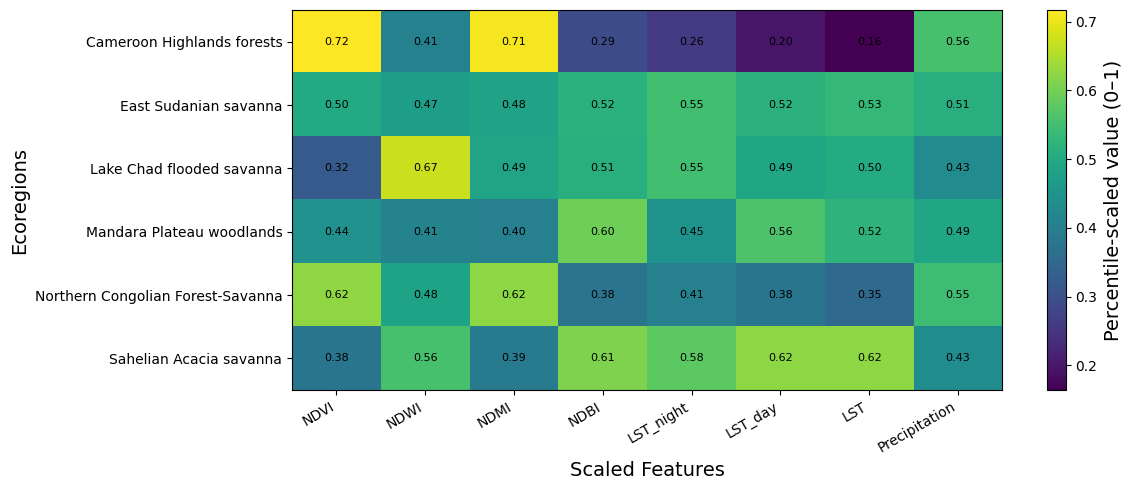

In [117]:
vals = datasets_all.values
row_labels = datasets_all.index.to_list()

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(vals, aspect="auto")  # default colormap

ax.set_xlabel("Scaled Features", size =14)
ax.set_ylabel("Ecoregions", size =14)

ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")

ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percentile-scaled value (0–1)", size =14)

# annotate cells
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f"{vals[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

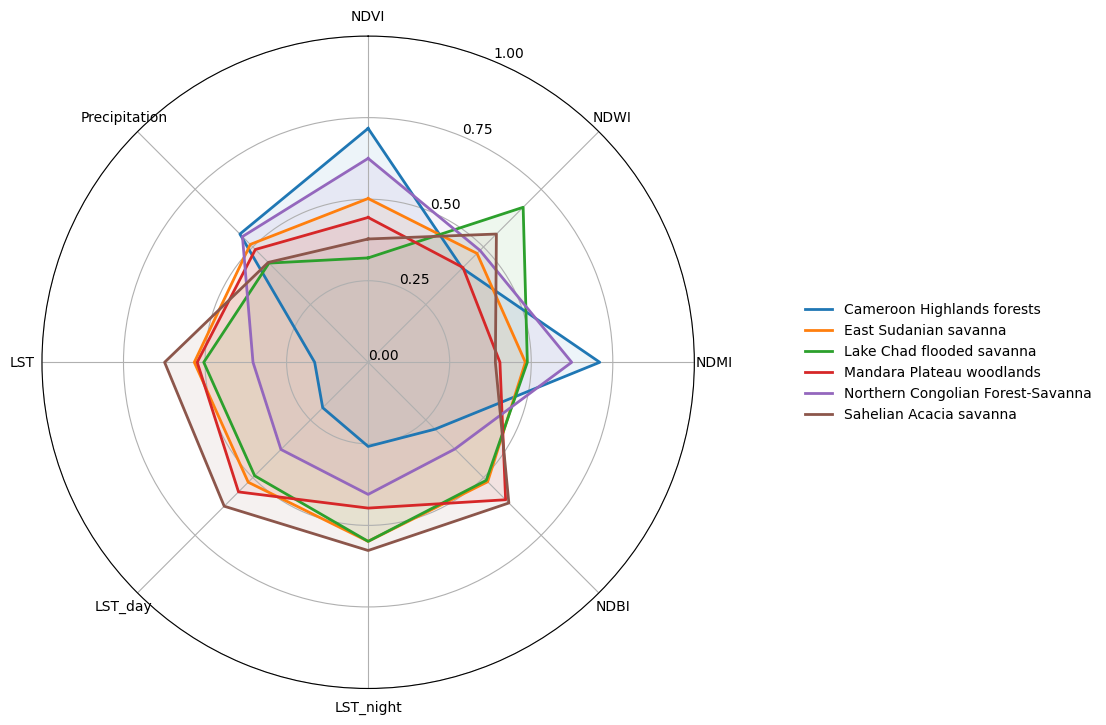

In [118]:
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(111, polar=True)

# start at top, go clockwise
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)
ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.00", "0.25", "0.50", "0.75", "1.00"])

for eco_name, row in datasets_all.iterrows():
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=eco_name)
    ax.fill(angles, values, alpha=0.08)

ax.legend(loc="center left", bbox_to_anchor=(1.15, 0.5), frameon=False)

plt.tight_layout()
plt.show()

In [119]:
temp_profile

,ndvi_season_amp,ndwi_season_amp,ndmi_season_amp,ndbi_season_amp,lst_day_season_amp,lst_night_season_amp,lst_season_amp,precipitation_season_amp,ndvi_mean_iqr,ndwi_mean_iqr,ndmi_mean_iqr,ndbi_mean_iqr,lst_day_mean_iqr,lst_night_mean_iqr,lst_mean_iqr,precipitation_mean_iqr
ECO_NAME,,,,,,,,,,,,,,,,
Cameroon Highlands forests,0.334288,0.106815,0.324284,0.324284,8.756580,3.627854,5.274178,486.284134,0.101706,0.104441,0.103931,0.103931,2.818596,3.474807,2.677463,110.112810
East Sudanian savanna,0.364171,0.081409,0.338877,0.338877,11.426982,6.486844,7.068778,439.515146,0.120699,0.083414,0.121330,0.121330,4.111469,2.246225,2.627438,93.059373
Lake Chad flooded savanna,0.196002,0.048443,0.226397,0.226397,9.940942,9.505519,9.694414,466.253907,0.164132,0.104779,0.290292,0.290292,10.275534,2.410592,5.355728,84.631944
Mandara Plateau woodlands,0.371736,0.089421,0.315837,0.315837,11.886240,5.914730,7.437735,431.410842,0.071796,0.063352,0.068171,0.068171,3.168317,2.421184,2.216338,67.946915
Northern Congolian Forest-Savanna,0.395043,0.117361,0.343519,0.343519,10.440493,6.222885,6.243337,467.827769,0.109269,0.100314,0.107205,0.107205,3.847288,2.516853,2.671715,99.881790
Sahelian Acacia savanna,0.314460,0.046921,0.322345,0.322345,13.038167,8.657373,8.724996,424.687703,0.101019,0.087220,0.104839,0.104839,4.138680,2.070016,2.414387,81.304290


In [120]:
eco_month_seasonal = eco_month[['ECO_NAME', 'month', 'ndvi_mean', 'ndvi_std', 'ndvi_median', 'ndvi_p25',
       'ndvi_p75', 'ndwi_mean', 'ndwi_std', 'ndwi_median', 'ndwi_p25',
       'ndwi_p75', 'ndmi_mean', 'ndmi_std', 'ndmi_median', 'ndmi_p25',
       'ndmi_p75', 'ndbi_mean', 'ndbi_std', 'ndbi_median', 'ndbi_p25',
       'ndbi_p75', 'lst_mean','lst_std', 'lst_median', 'lst_p25', 'lst_p75', 'precipitation_mean',
       'precipitation_std', 'precipitation_median', 'precipitation_p25',
       'precipitation_p75']].copy()


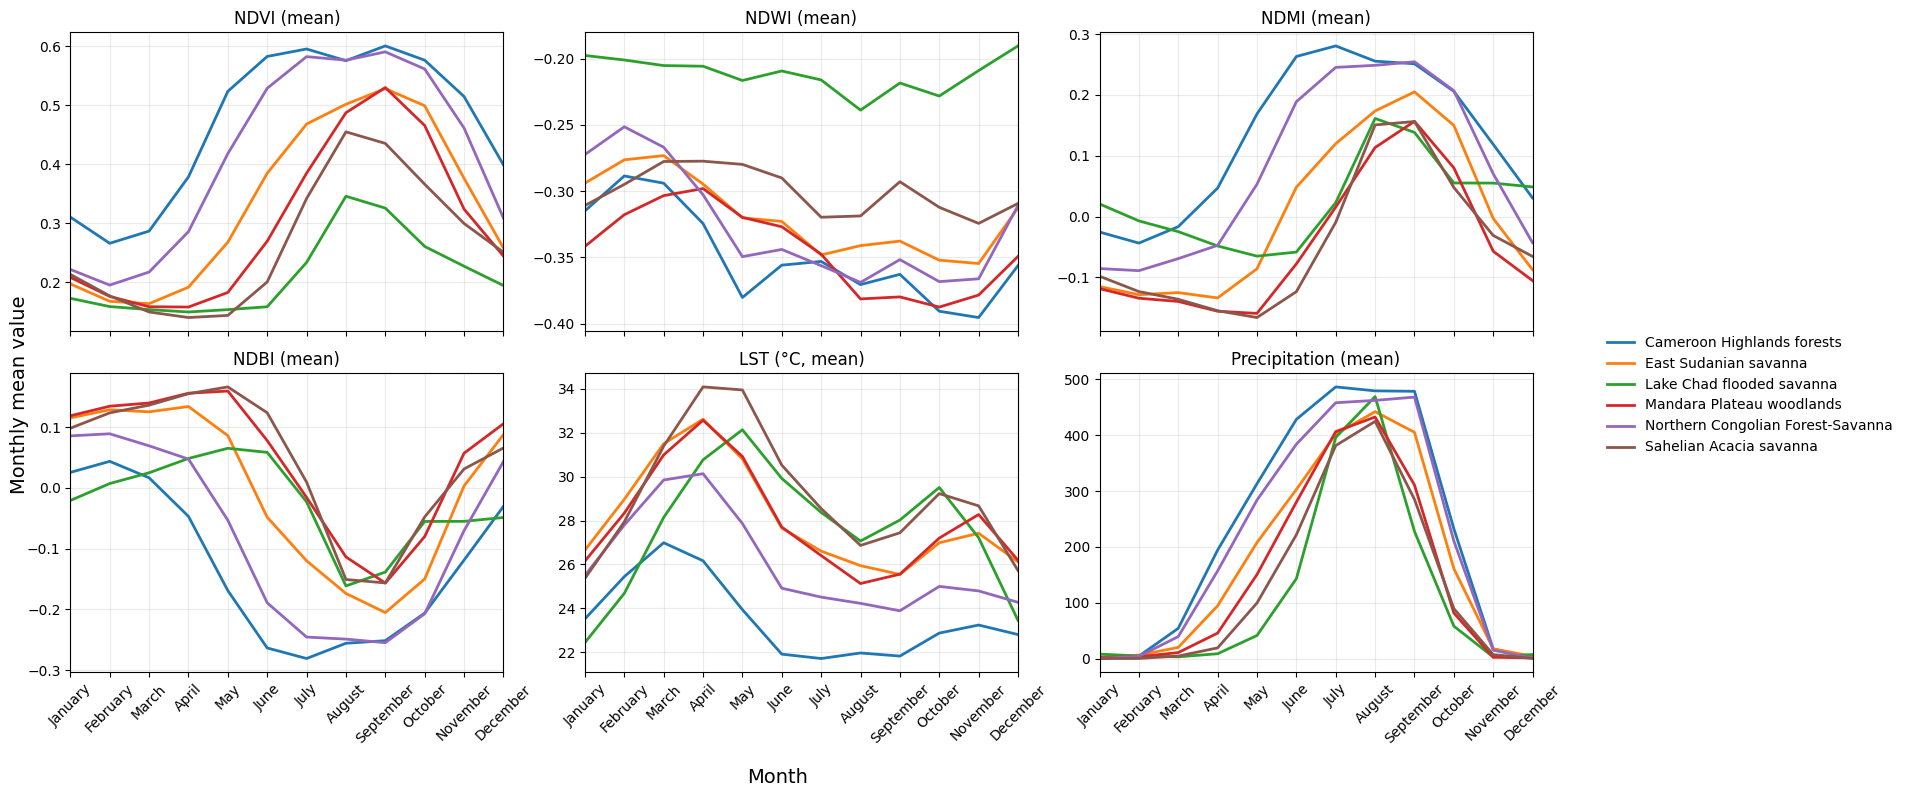

In [121]:
eco_month_seasonal["month"] = eco_month_seasonal["month"].astype(int)
eco_month_seasonal = eco_month_seasonal.sort_values(["ECO_NAME", "month"])

# Variables to plot (monthly climatology using MEAN)
vars_to_plot = [
    ("ndvi_mean", "NDVI (mean)"),
    ("ndwi_mean", "NDWI (mean)"),
    ("ndmi_mean", "NDMI (mean)"),
    ("ndbi_mean", "NDBI (mean)"),
    ("lst_mean", "LST (°C, mean)"),
    ("precipitation_mean", "Precipitation (mean)"),
]

ecoregions = eco_month["ECO_NAME"].unique()
months = np.arange(1, 13)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8), sharex=True)
axes = axes.ravel()

for ax, (col, title) in zip(axes, vars_to_plot):
    for eco in ecoregions:
        sub = eco_month.loc[eco_month["ECO_NAME"] == eco, ["month", col]].dropna()

        # Ensure months 1..12 order and fill gaps (if any) with NaN
        s = sub.set_index("month")[col].reindex(months)

        ax.plot(months, s.values, linewidth=2, label=eco)

    ax.set_title(title)
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels, rotation=45)
    ax.set_xlim(1, 12)
    ax.grid(True, alpha=0.25)

# Common labels
#fig.suptitle("FIGUREX: Monthly climatology curves showing mean seasonal variation of environmental indicators across ecoregions", y=1.02)
fig.supxlabel("Month", size =14)
fig.supylabel("Monthly mean value", size = 14)

# One legend for the whole figure (outside)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.tight_layout()
plt.show()


In [122]:
vars_to_use = [
    "ndvi_mean",
    "ndwi_mean",
    "ndmi_mean",
    "ndbi_mean",
    "lst_mean",
    "precipitation_mean"
]


# Compute seasonal amplitude: max(monthly mean) - min(monthly mean)
seasonal_amplitude = (
    eco_month_seasonal
    .groupby("ECO_NAME")[vars_to_use]
    .agg(lambda x: x.max() - x.min())
    .rename(columns={
        "ndvi_mean": "NDVI amplitude",
        "ndwi_mean": "NDWI amplitude",
        "ndmi_mean": "NDMI amplitude",
        "ndbi_mean": "NDBI amplitude",
        "lst_mean": "LST amplitude",
        "precipitation_mean": "PRECIPITATION amplitude"
    })
)

seasonal_amplitude = seasonal_amplitude.round(3)
seasonal_amplitude

,NDVI amplitude,NDWI amplitude,NDMI amplitude,NDBI amplitude,LST amplitude,PRECIPITATION amplitude
ECO_NAME,,,,,,
Cameroon Highlands forests,0.334,0.107,0.324,0.324,5.274,486.284
East Sudanian savanna,0.364,0.081,0.339,0.339,7.069,439.515
Lake Chad flooded savanna,0.196,0.048,0.226,0.226,9.694,466.254
Mandara Plateau woodlands,0.372,0.089,0.316,0.316,7.438,431.411
Northern Congolian Forest-Savanna,0.395,0.117,0.344,0.344,6.243,467.828
Sahelian Acacia savanna,0.314,0.047,0.322,0.322,8.725,424.688


In [123]:
vars_base = [
    "ndvi",
    "ndwi",
    "ndmi",
    "ndbi",
    "lst",
    "precipitation"
]

# Construct column names
std_cols = [f"{v}_std" for v in vars_base]
p25_cols = [f"{v}_p25" for v in vars_base]
p75_cols = [f"{v}_p75" for v in vars_base]


eco_month_iqr = eco_month_seasonal.copy()

for v in vars_base:
    eco_month_iqr[f"{v}_iqr"] = eco_month_iqr[f"{v}_p75"] - eco_month_iqr[f"{v}_p25"]

iqr_cols = [f"{v}_iqr" for v in vars_base]

variability_table = (eco_month_iqr.groupby("ECO_NAME")[std_cols + iqr_cols].mean())

rename_map = {}

for v in vars_base:
    rename_map[f"{v}_std"] = f"{v.upper()} monthly STD"
    rename_map[f"{v}_iqr"] = f"{v.upper()} monthly IQR"

variability_table = variability_table.rename(columns=rename_map)

variability_table = variability_table.round(3)

variability_table

,NDVI monthly STD,NDWI monthly STD,NDMI monthly STD,NDBI monthly STD,LST monthly STD,PRECIPITATION monthly STD,NDVI monthly IQR,NDWI monthly IQR,NDMI monthly IQR,NDBI monthly IQR,LST monthly IQR,PRECIPITATION monthly IQR
ECO_NAME,,,,,,,,,,,,
Cameroon Highlands forests,0.077,0.075,0.078,0.078,2.017,108.100,0.102,0.104,0.104,0.104,2.677,110.113
East Sudanian savanna,0.111,0.113,0.097,0.097,2.001,92.597,0.121,0.083,0.121,0.121,2.627,93.059
Lake Chad flooded savanna,0.194,0.220,0.196,0.196,2.992,78.621,0.164,0.105,0.290,0.290,5.356,84.632
Mandara Plateau woodlands,0.057,0.048,0.055,0.055,1.618,70.798,0.072,0.063,0.068,0.068,2.216,67.947
Northern Congolian Forest-Savanna,0.082,0.074,0.080,0.080,2.028,97.426,0.109,0.100,0.107,0.107,2.672,99.882
Sahelian Acacia savanna,0.085,0.087,0.102,0.102,1.894,69.698,0.101,0.087,0.105,0.105,2.414,81.304


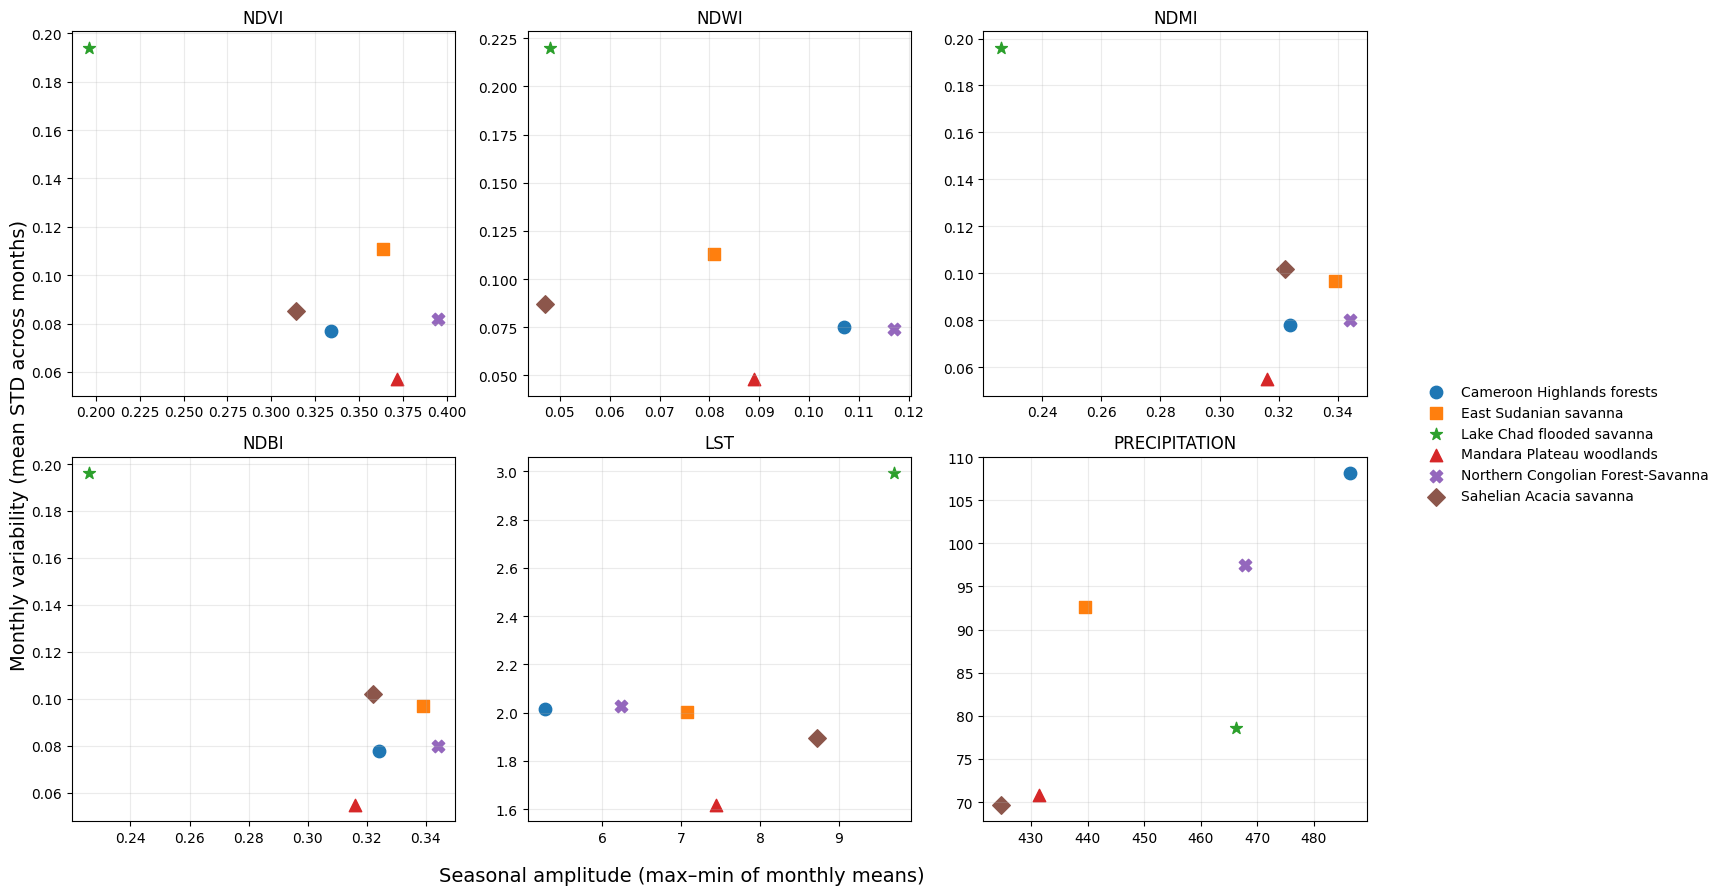

In [124]:
# --- Assumes these already exist ---
# seasonal_amplitude: index ECO_NAME, cols like "NDVI amplitude", "LST amplitude", ...
# variability_table : index ECO_NAME, cols like "NDVI monthly IQR" / "NDVI monthly STD", ...

USE_VARIABILITY = "STD"   # switch to "STD" if preferred

# Canonical variables you want to compare
vars_base = ["NDVI", "NDWI", "NDMI", "NDBI", "LST", "PRECIPITATION"]

# Pick the right variability columns
if USE_VARIABILITY.upper() == "STD":
    var_colnames = {v: f"{v} monthly STD" for v in vars_base}
else:
    var_colnames = {v: f"{v} monthly IQR" for v in vars_base}

amp_colnames = {v: f"{v} amplitude" for v in vars_base}

# Keep only variables that exist in both tables
available_vars = [
    v for v in vars_base
    if amp_colnames[v] in seasonal_amplitude.columns and var_colnames[v] in variability_table.columns
]

# Ensure same ecoregions
common_ecos = seasonal_amplitude.index.intersection(variability_table.index)

# Build plotting frame (long format)
rows = []
for v in available_vars:
    a = seasonal_amplitude.loc[common_ecos, amp_colnames[v]]
    y = variability_table.loc[common_ecos, var_colnames[v]]
    tmp = pd.DataFrame({"ECO_NAME": common_ecos, "variable": v, "amplitude": a.values, "variability": y.values})
    rows.append(tmp)

df_plot = pd.concat(rows, ignore_index=True)

# -------------------------
# Plot: one panel per variable
# -------------------------
ecoregions = df_plot["ECO_NAME"].unique().tolist()
markers = ["o", "s",  "*","^", "X", "D", "v", "P", "<", ">", "h", "H"]  # enough for most cases
marker_map = {eco: markers[i % len(markers)] for i, eco in enumerate(ecoregions)}

n = len(available_vars)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
axes = np.array(axes).ravel()

for i, v in enumerate(available_vars):
    ax = axes[i]
    sub = df_plot[df_plot["variable"] == v]

    for eco in ecoregions:
        pts = sub[sub["ECO_NAME"] == eco]
        ax.scatter(pts["amplitude"], pts["variability"], s=80, marker=marker_map[eco], label=eco)

    ax.set_title(v)
    ax.grid(True, alpha=0.25)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# One legend for all panels (outside)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

#fig.suptitle(f"Amplitude vs Variability by Variable ({USE_VARIABILITY.upper()})", y=1.02)
fig.supxlabel("Seasonal amplitude (max–min of monthly means)", size =14)
if USE_VARIABILITY.upper() == "STD":
    fig.supylabel("Monthly variability (mean STD across months)", size = 14)
else:
    fig.supylabel("Monthly variability (mean IQR across months)", size = 14)


plt.tight_layout()
plt.show()


In [125]:
malaria_data = pd.read_csv('../../data/CM_MAL_cases_GID2_2015-2024_processed.csv', encoding = enc)

In [126]:
malaria_data["dt_placement"] = pd.to_datetime(malaria_data["dt_placement"], format="%Y-%m")
malaria_data["month"] = malaria_data["dt_placement"].dt.month
malaria_data["year"] = malaria_data["dt_placement"].dt.year

malaria_df = malaria_data[['month', 'Case_UND5', 'Case_TOTAL']].copy()

In [127]:
cols = ["Case_TOTAL", "Case_UND5"]

clim_mean = malaria_df.groupby("month")[cols].mean().reindex(range(1, 13))
clim_sum = malaria_df.groupby("month")[cols].sum().reindex(range(1, 13))
clim_p25  = malaria_df.groupby("month")[cols].quantile(0.25).reindex(range(1, 13))
clim_p75  = malaria_df.groupby("month")[cols].quantile(0.75).reindex(range(1, 13))
clim_std  = malaria_df.groupby("month")[cols].std().reindex(range(1, 13))

months = np.arange(1, 13)

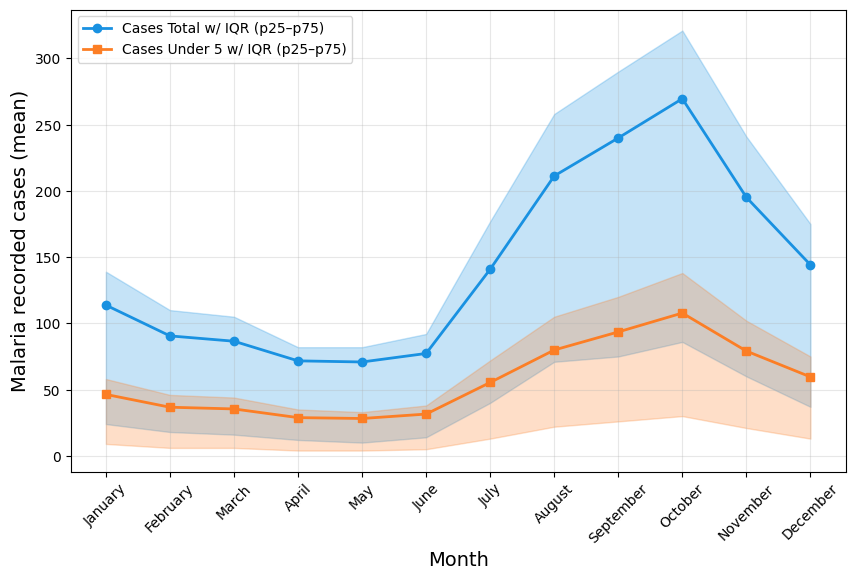

In [128]:
BAND = "IQR"   # "STD" or "IQR"

fig, ax = plt.subplots(figsize=(10, 6))

if BAND.upper() == "STD":
    lower_total = clim_mean["Case_TOTAL"] - clim_std["Case_TOTAL"]
    upper_total = clim_mean["Case_TOTAL"] + clim_std["Case_TOTAL"]
    lower_u5 = clim_mean["Case_UND5"] - clim_std["Case_UND5"]
    upper_u5 = clim_mean["Case_UND5"] + clim_std["Case_UND5"]
    band_label = " ± STD"
else: 
    lower_total = clim_p25["Case_TOTAL"]
    upper_total = clim_p75["Case_TOTAL"]
    lower_u5 = clim_p25["Case_UND5"]
    upper_u5 = clim_p75["Case_UND5"]
    band_label = " w/ IQR (p25–p75)"

# ----- TOTAL -----
ax.plot(months,clim_mean["Case_TOTAL"],linewidth=2,marker="o",label=f"Cases Total{band_label}",color="#1991e1")
ax.fill_between(months,lower_total,upper_total,alpha=0.25,color="#1991e1")

# ----- UNDER 5 -----
ax.plot(months,clim_mean["Case_UND5"],linewidth=2,marker="s",label=f"Cases Under 5{band_label}",color="#fc7e25")
ax.fill_between(months,lower_u5,upper_u5,alpha=0.25,color="#fc7e25")

ax.set_xlabel("Month", size=14)
ax.set_ylabel("Malaria recorded cases (mean)", size=14)
ax.set_xticks(months)
ax.set_xticklabels(month_labels, rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

In [197]:
malaria_lag = malaria_data[['year','month', 'Case_UND5', 'Case_TOTAL']].copy()

malaria_monthly_totals = (malaria_lag.groupby(["year", "month"], as_index=False)[["Case_TOTAL", "Case_UND5"]]
                          .sum()
                          .sort_values(["year", "month"]))

eo_df = gdf_eco[['year', 'month', 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'lst', 'precipitation']].copy()

eo_vars = ["ndvi", "ndwi", "ndmi", "ndbi", "lst", "precipitation"]

eo_monthly_totals = (eo_df.groupby(["year", "month"], as_index=False)[eo_vars]
                    .mean()
                    .sort_values(["year", "month"]))

eo_monthly_std = (eo_df.groupby(["year", "month"], as_index=False)[eo_vars]
                .std()
                .rename(columns={v: f"{v}_std" for v in eo_vars}))

In [198]:
aligned = malaria_monthly_totals.merge(eo_monthly_totals,on=["year", "month"],how="inner")
aligned = aligned.merge(eo_monthly_std, on=["year", "month"], how="left")
aligned["date"] = pd.to_datetime(aligned["year"].astype(str) + "-" + aligned["month"].astype(str).str.zfill(2) + "-01"
    )
aligned = aligned.sort_values("date").reset_index(drop=True)

aligned = aligned[['date', 'year', 'month', 'Case_TOTAL', 'Case_UND5', 'ndvi', 'ndwi', 'ndmi',
       'ndbi', 'lst', 'precipitation', 'ndvi_std', 'ndwi_std', 'ndmi_std',
       'ndbi_std', 'lst_std', 'precipitation_std']].copy()

In [207]:
lag_months = [0, 1, 2, 3]

mean_vars = ["ndvi", "ndwi", "ndmi", "ndbi", "lst", "precipitation"]
std_vars  = ["ndvi_std", "ndwi_std", "ndmi_std", "ndbi_std", "lst_std", "precipitation_std"]

targets = ["Case_TOTAL", "Case_UND5"]

df_lag = aligned.sort_values("date").copy()

def lag_corr_and_pvals(df: pd.DataFrame, vars_list, target_col: str, lags):
    """
    Returns:
      corr_df:  rows=vars_list, cols=lags, values=Pearson r
      pval_df:  rows=vars_list, cols=lags, values=p-value from scipy.stats.pearsonr
    """
    corr_df = pd.DataFrame(index=vars_list, columns=lags, dtype=float)
    pval_df = pd.DataFrame(index=vars_list, columns=lags, dtype=float)

    for var in vars_list:
        for lag in lags:
            shifted = df[var].shift(lag)

            # Correlation (pandas handles alignment + NaNs)
            corr_df.loc[var, lag] = df[target_col].corr(shifted)

            # P-value (explicitly drop NaNs on the paired series)
            valid = pd.concat([df[target_col], shifted.rename(var)], axis=1).dropna()
            if len(valid) >= 2:
                _, p = pearsonr(valid[target_col], valid[var])
                pval_df.loc[var, lag] = p
            else:
                pval_df.loc[var, lag] = float("nan")

    return corr_df, pval_df

# Build all outputs in a compact structure
results = {}
for target in targets:
    results[(target, "mean", "corr")], results[(target, "mean", "pval")] = lag_corr_and_pvals(df_lag, mean_vars, target, lag_months)
    results[(target, "std",  "corr")], results[(target, "std",  "pval")] = lag_corr_and_pvals(df_lag, std_vars,  target, lag_months)

lag_corr_mean_TOTAL = results[("Case_TOTAL", "mean", "corr")]
lag_corr_mean_UND5  = results[("Case_UND5",  "mean", "corr")]
lag_corr_std_TOTAL  = results[("Case_TOTAL", "std",  "corr")]
lag_corr_std_UND5   = results[("Case_UND5",  "std",  "corr")]

lag_pval_mean_TOTAL = results[("Case_TOTAL", "mean", "pval")]
lag_pval_mean_UND5  = results[("Case_UND5",  "mean", "pval")]
lag_pval_std_TOTAL  = results[("Case_TOTAL", "std",  "pval")]
lag_pval_std_UND5   = results[("Case_UND5",  "std",  "pval")]

sig_mean_TOTAL = lag_pval_mean_TOTAL < 0.05
sig_mean_UND5 = lag_pval_mean_UND5 < 0.05
sig_std_TOTAL = lag_pval_std_TOTAL < 0.05
sig_std_UND5 = lag_pval_std_UND5 < 0.05


In [257]:
def plot_lag_corr_side_by_side_with_stars(
    lag_corr_mean,
    lag_corr_std,
    lag_pval_mean,
    lag_pval_std,
    target_label="Case_TOTAL",
    figsize=(12, 6),
    vmin=-0.8,
    vmax=0.8,
    reverse_lags=True,
    x_labels=None,
    y_label="Environmental Variable",
    x_label="Lag (months)",
    show_star_legend=True,
):
    mean_rev = lag_corr_mean.iloc[:, ::-1].copy() if reverse_lags else lag_corr_mean.copy()
    std_rev  = lag_corr_std.iloc[:, ::-1].copy()  if reverse_lags else lag_corr_std.copy()

    p_mean_rev = lag_pval_mean.iloc[:, ::-1].copy() if reverse_lags else lag_pval_mean.copy()
    p_std_rev  = lag_pval_std.iloc[:, ::-1].copy()  if reverse_lags else lag_pval_std.copy()

    std_rev.index = std_rev.index.to_series().str.replace(r"_std$", "", regex=True)
    p_std_rev.index = p_std_rev.index.to_series().str.replace(r"_std$", "", regex=True)

    std_rev   = std_rev.reindex(index=mean_rev.index, columns=mean_rev.columns)
    p_std_rev = p_std_rev.reindex(index=mean_rev.index, columns=mean_rev.columns)

    if x_labels is None:
        x_labels = ["-3", "-2", "-1", "0"] if reverse_lags else [str(c) for c in mean_rev.columns]

    corr_m = mean_rev.to_numpy()
    corr_s = std_rev.to_numpy()

    p_m = p_mean_rev.to_numpy()
    p_s = p_std_rev.to_numpy()

    def stars_from_p(p_arr):
        stars = np.full(p_arr.shape, "", dtype=object)
        stars[p_arr < 0.05] = "*"
        stars[p_arr < 0.01] = "**"
        stars[p_arr < 0.001] = "***"
        return stars

    stars_m = stars_from_p(p_m)
    stars_s = stars_from_p(p_s)

    annot_m = np.empty(corr_m.shape, dtype=object)
    annot_s = np.empty(corr_s.shape, dtype=object)

    for i in range(corr_m.shape[0]):
        for j in range(corr_m.shape[1]):
            annot_m[i, j] = f"{corr_m[i, j]:.2f}\n{stars_m[i, j]}"
            annot_s[i, j] = f"{corr_s[i, j]:.2f}\n{stars_s[i, j]}"

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05])

    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharey=ax1)
    cbar_ax = fig.add_subplot(gs[2])

    sns.heatmap(
        mean_rev,
        ax=ax1,
        annot=annot_m, fmt="",
        cmap="coolwarm", center=0,
        vmin=vmin, vmax=vmax,
        linewidths=0.5,
        cbar=False,
        annot_kws={"color": "black"}
    )

    sns.heatmap(
        std_rev,
        ax=ax2,
        annot=annot_s, fmt="",
        cmap="coolwarm", center=0,
        vmin=vmin, vmax=vmax,
        linewidths=0.5,
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={"label": "Pearson r"},
        annot_kws={"color": "black"}
    )

    cbar_ax.set_ylabel("Pearson r", fontsize=14)
    cbar_ax.tick_params(labelsize=12)

    # ax1.set_title("Mean")
    # ax2.set_title("Standard Deviation")
    ax2.tick_params(axis="y", left=False, labelleft=False)
    ax1.set_xticklabels(x_labels, rotation=0)
    ax2.set_xticklabels(x_labels, rotation=0)
    ax1.tick_params(axis="y", labelrotation=45)
    fig.supxlabel(x_label, fontsize=14)
    fig.supylabel(y_label, fontsize=14)

    fig.suptitle(
        f"Lag Correlation of EO Indicators (mean, std) with {target_label}",
        fontsize=14,
    )

    # Star legend
    if show_star_legend:
        fig.text(
            0.97, -0.01,
            "no symbol: p≥0.05\n* p<0.05 \n** p<0.01 \n*** p<0.001",
            ha="right",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


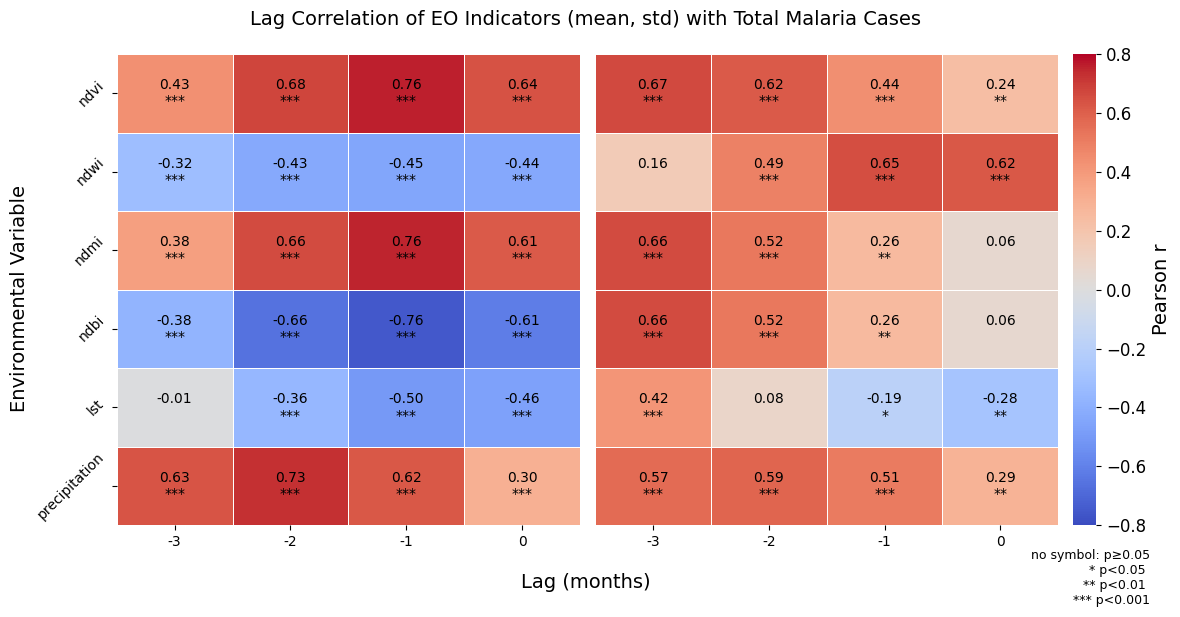

In [258]:
plot_lag_corr_side_by_side_with_stars(
    lag_corr_mean_TOTAL,
    lag_corr_std_TOTAL,
    lag_pval_mean_TOTAL,
    lag_pval_std_TOTAL,
    target_label="Total Malaria Cases"
)


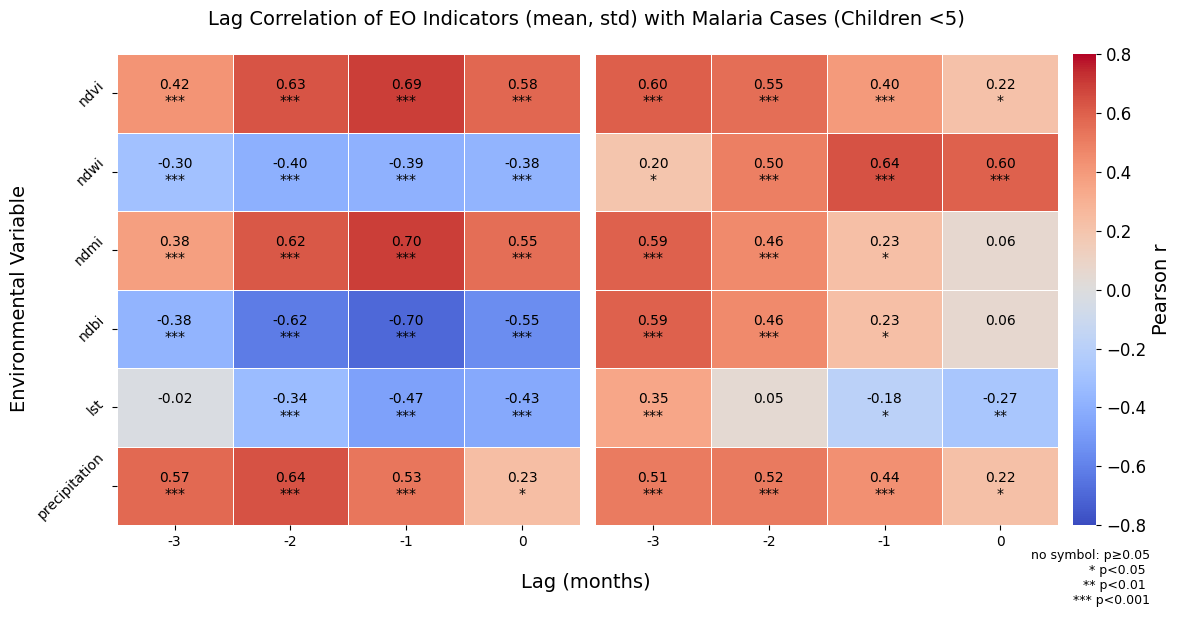

In [259]:
plot_lag_corr_side_by_side_with_stars(
    lag_corr_mean_UND5,
    lag_corr_std_UND5,
    lag_pval_mean_UND5,
    lag_pval_std_UND5,
    target_label="Malaria Cases (Children <5)"
)

In [ ]:
# eco_month.to_csv(f'../../data/Ecoregions/eco_month.csv', index=False)
# abs_profile.to_csv(f'../../data/Ecoregions/abs_profile.csv')
# rel_profile.to_csv(f'../../data/Ecoregions/rel_profile.csv')
# temp_profile.to_csv(f'../../data/Ecoregions/temp_profile.csv')
# malaria_df.to_csv(f'../../data/Ecoregions/malaria_monthly.csv', index=False)
# eco_month[['ECO_NAME', 'month', 'ndvi_mean', 'ndvi_std', 'ndvi_median', 'ndvi_p25',
#        'ndvi_p75', 'ndwi_mean', 'ndwi_std', 'ndwi_median', 'ndwi_p25',
#        'ndwi_p75', 'ndmi_mean', 'ndmi_std', 'ndmi_median', 'ndmi_p25',
#        'ndmi_p75', 'ndbi_mean', 'ndbi_std', 'ndbi_median', 'ndbi_p25',
#        'ndbi_p75', 'lst_mean','lst_std', 'lst_median', 'lst_p25', 'lst_p75', 'precipitation_mean',
#        'precipitation_std', 'precipitation_median', 'precipitation_p25',
#        'precipitation_p75']].to_csv(f'../../data/Ecoregions/eco_month_raw.csv', index=False)
